# AML Suspicious Subgraph Discovery Team 36-QCI

This notebook implements the Phase 2 prototype for the Quantum Dice AML challenge.

Pipeline:

1. Generate or load a transaction graph
2. Assign node and edge suspicion scores
3. Select high-risk seed accounts
4. Perform risk-guided BFS/DFS expansion
5. Apply community refinement and recursive splitting
6. Formulate local QUBO problems
7. Solve using a probabilistic / annealing-style solver
8. Consolidate overlapping suspicious clusters
9. Visualize and explain detected suspicious cases


# Setup

We start with standard Python graph/data libraries.


In [ ]:
import random
import math
from collections import deque, defaultdict
import time
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)


# Preprocessing

## 2. Loading the Transaction Graph


We construct a weighted directed transaction graph from the IBM AML dataset, where nodes represent accounts and edges represent aggregated transactions.


In [ ]:
# LOAD WITH HF
BASE_URL = "https://huggingface.co/datasets/OsamaMIT/IBM-AML-HI-Small/resolve/main"

transactions_df = pd.read_csv(f"{BASE_URL}/HI-Small_Trans.csv")
accounts_df = pd.read_csv(f"{BASE_URL}/HI-Small_accounts.csv")

print("Transactions:", transactions_df.shape)
print("Accounts:", accounts_df.shape)

display(transactions_df.head())
display(accounts_df.head())

Transactions: (5078345, 11)
Accounts: (518581, 5)


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


,Bank Name,Bank ID,Account Number,Entity ID,Entity Name
0,Portugal Bank #4507,331579,80B779D80,80062E240,Sole Proprietorship #50438
1,Canada Bank #27,210,809D86900,800C998A0,Corporation #33520
2,UK Bank #33,21884,80812BE00,800C47F50,Partnership #35397
3,Germany Bank #4815,32742,81047F300,80096F0B0,Corporation #48813
4,National Bank of Harrisburg,127390,80BD8CF00,800FB8760,Corporation #889


In [ ]:
def build_transaction_graph_from_df(
    transactions_df,
    accounts_df=None,
    max_transactions=None,
    remove_self_loops=True,
):

    df = transactions_df.copy()

    if max_transactions is not None:
        df = df.head(max_transactions).copy()

    # Clean column names only inside this function
    df = df.rename(columns={
        "Account": "src_account",
        "Account.1": "dst_account",
        "From Bank": "src_bank",
        "To Bank": "dst_bank",
        "Amount Paid": "amount_paid",
        "Amount Received": "amount_received",
        "Payment Currency": "payment_currency",
        "Receiving Currency": "receiving_currency",
        "Payment Format": "payment_format",
        "Is Laundering": "is_laundering",
        "Timestamp": "timestamp",
    })

    df["amount_paid"] = pd.to_numeric(df["amount_paid"], errors="coerce").fillna(0.0)
    df["amount_received"] = pd.to_numeric(df["amount_received"], errors="coerce").fillna(0.0)
    df["is_laundering"] = pd.to_numeric(df["is_laundering"], errors="coerce").fillna(0).astype(int)

    if remove_self_loops:
        df = df[df["src_account"] != df["dst_account"]].copy()

    G = nx.DiGraph()


    # Aggregate multiple transactions between the same ordered account pair
    grouped = df.groupby(["src_account", "dst_account"], sort=False)

    for (src, dst), group in grouped:
        payment_formats = tuple(sorted(group["payment_format"].dropna().unique()))
        currencies = tuple(sorted(group["payment_currency"].dropna().unique()))

        G.add_edge(
            src,
            dst,
            amount_total=float(group["amount_paid"].sum()),
            amount_mean=float(group["amount_paid"].mean()),
            amount_max=float(group["amount_paid"].max()),
            frequency=int(len(group)),
            laundering_count=int(group["is_laundering"].sum()),
            laundering_ratio=float(group["is_laundering"].mean()),
            payment_formats=payment_formats,
            currencies=currencies,
            first_timestamp=group["timestamp"].min(),
            last_timestamp=group["timestamp"].max(),
        )

        # Add lightweight node labels for evaluation/debugging
        G.nodes[src]["has_laundering_activity"] = (
            G.nodes[src].get("has_laundering_activity", False)
            or bool(group["is_laundering"].any())
        )
        G.nodes[dst]["has_laundering_activity"] = (
            G.nodes[dst].get("has_laundering_activity", False)
            or bool(group["is_laundering"].any())
        )

    return G
def make_stage2_transaction_sample(
    transactions_df,
    max_transactions=500_000,
    label_col="Is Laundering",
    src_col="Account",
    dst_col="Account.1",
    random_state=42,
    context_fraction=0.60,
):
    df = transactions_df.copy()

    if max_transactions is None or len(df) <= max_transactions:
        return df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)

    if label_col not in df.columns:
        return df.sample(n=max_transactions, random_state=random_state).reset_index(drop=True)

    labels = pd.to_numeric(df[label_col], errors="coerce").fillna(0).astype(int)

    laundering_df = df[labels == 1].copy()
    normal_df = df[labels == 0].copy()

    if len(laundering_df) == 0:
        return df.sample(n=max_transactions, random_state=random_state).reset_index(drop=True)

    if len(laundering_df) >= max_transactions:
        return laundering_df.sample(n=max_transactions, random_state=random_state).reset_index(drop=True)

    remaining_budget = max_transactions - len(laundering_df)

    laundering_accounts = set(laundering_df[src_col].astype(str)) | set(laundering_df[dst_col].astype(str))

    context_mask = (
        normal_df[src_col].astype(str).isin(laundering_accounts)
        | normal_df[dst_col].astype(str).isin(laundering_accounts)
    )

    context_df = normal_df[context_mask].copy()
    background_df = normal_df[~context_mask].copy()

    n_context = min(len(context_df), int(remaining_budget * context_fraction))
    context_sample = (
        context_df.sample(n=n_context, random_state=random_state)
        if n_context > 0
        else context_df.head(0)
    )

    remaining_budget -= len(context_sample)

    n_background = min(len(background_df), remaining_budget)
    background_sample = (
        background_df.sample(n=n_background, random_state=random_state)
        if n_background > 0
        else background_df.head(0)
    )

    sample_df = pd.concat(
        [laundering_df, context_sample, background_sample],
        axis=0,
    )

    if len(sample_df) < max_transactions:
        leftover_df = df.drop(index=sample_df.index, errors="ignore")
        n_extra = min(len(leftover_df), max_transactions - len(sample_df))
        if n_extra > 0:
            extra_df = leftover_df.sample(n=n_extra, random_state=random_state)
            sample_df = pd.concat([sample_df, extra_df], axis=0)

    return sample_df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)

transactions_sample_df = make_stage2_transaction_sample(
    transactions_df,
    max_transactions=500_000,
    random_state=42,
)

G = build_transaction_graph_from_df(
    transactions_sample_df,
    accounts_df=accounts_df,
    max_transactions=None, # use None for full dataset, small value for quick tests
    remove_self_loops=True,
)

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

Nodes: 196343
Edges: 183004


## 3. Node and Edge Suspicion Scoring

We normalize and assign risk scores to edges and nodes in preparation for the graph splicing.


In [ ]:
def normalize(values, default=0.0, log_scale=False, clip_percentile=None):
    values = np.array(values, dtype=float)

    values = np.nan_to_num(values, nan=0.0, posinf=0.0, neginf=0.0)

    if log_scale:
        values = np.log1p(np.maximum(values, 0.0))

    if clip_percentile is not None:
        upper = np.percentile(values, clip_percentile)
        values = np.clip(values, 0.0, upper)

    v_min = values.min()
    v_max = values.max()

    if v_max == v_min:
        return np.ones_like(values) * default

    return (values - v_min) / (v_max - v_min)


def score_edges(
    G,
    use_label_for_scoring=False,
    amount_weight=0.35,
    frequency_weight=0.30,
    bidirectional_weight=0.20,
    format_weight=0.15,
    label_weight=0.0,
):

    edges = list(G.edges(data=True))

    if not edges:
        return

    amount_totals = [data.get("amount_total", 0.0) for _, _, data in edges]
    frequencies = [data.get("frequency", 1.0) for _, _, data in edges]

    amount_norm = normalize(amount_totals, default=0.0, log_scale=True, clip_percentile=99)
    freq_norm = normalize(frequencies, default=0.0, log_scale=True, clip_percentile=99)

    payment_format_risk = {
        "Cash": 1.00,
        "Cheque": 0.80,
        "ACH": 0.55,
        "Wire": 0.55,
        "Credit Card": 0.35,
        "Reinvestment": 0.10,
        "Bitcoin": 0.90,
    }

    for idx, (u, v, data) in enumerate(edges):
        # Bidirectional movement can indicate circular or layered flow
        bidirectional = 1.0 if G.has_edge(v, u) else 0.0

        formats = data.get("payment_formats", ())
        if isinstance(formats, str):
            formats = (formats,)

        if formats:
            fmt_score = max(payment_format_risk.get(fmt, 0.40) for fmt in formats)
        else:
            fmt_score = 0.40

        risk = (
            amount_weight * amount_norm[idx]
            + frequency_weight * freq_norm[idx]
            + bidirectional_weight * bidirectional
            + format_weight * fmt_score
        )

        if use_label_for_scoring:
            laundering_ratio = float(data.get("laundering_ratio", 0.0))
            risk += label_weight * laundering_ratio

        data["edge_risk"] = float(np.clip(risk, 0.0, 1.0))


def score_nodes(
    G,
    edge_risk_weight=0.45,
    degree_weight=0.25,
    flow_weight=0.20,
    activity_weight=0.10,
):

    if G.number_of_nodes() == 0:
        return

    UG = G.to_undirected()
    degree_cent = nx.degree_centrality(UG)

    raw_activity = {}
    raw_flow_balance = {}
    raw_avg_edge_risk = {}

    for node in G.nodes():
        incident_risks = []
        amount_in = 0.0
        amount_out = 0.0
        tx_count = 0

        for _, _, data in G.in_edges(node, data=True):
            incident_risks.append(float(data.get("edge_risk", 0.0)))
            amount_in += float(data.get("amount_total", 0.0))
            tx_count += int(data.get("frequency", 1))

        for _, _, data in G.out_edges(node, data=True):
            incident_risks.append(float(data.get("edge_risk", 0.0)))
            amount_out += float(data.get("amount_total", 0.0))
            tx_count += int(data.get("frequency", 1))

        avg_edge_risk = float(np.mean(incident_risks)) if incident_risks else 0.0

        # Pass-through behavior: high if incoming and outgoing amounts are both large and similar.
        total_flow = amount_in + amount_out
        if total_flow > 0:
            flow_balance = 1.0 - abs(amount_in - amount_out) / total_flow
        else:
            flow_balance = 0.0

        raw_avg_edge_risk[node] = avg_edge_risk
        raw_flow_balance[node] = flow_balance
        raw_activity[node] = tx_count

    activity_norm_values = normalize(
        [raw_activity[n] for n in G.nodes()],
        default=0.0,
        log_scale=True,
        clip_percentile=99,
    )

    activity_norm = {
        node: float(activity_norm_values[idx])
        for idx, node in enumerate(G.nodes())
    }

    for node in G.nodes():
        node_risk = (
            edge_risk_weight * raw_avg_edge_risk[node]
            + degree_weight * degree_cent.get(node, 0.0)
            + flow_weight * raw_flow_balance[node]
            + activity_weight * activity_norm[node]
        )

        G.nodes[node]["node_risk"] = float(np.clip(node_risk, 0.0, 1.0))


score_edges(G, use_label_for_scoring=False)
score_nodes(G)

node_risks = pd.DataFrame({
    "node": list(G.nodes()),
    "risk": [G.nodes[n]["node_risk"] for n in G.nodes()],
    "has_laundering_activity": [
        G.nodes[n].get("has_laundering_activity", False)
        for n in G.nodes()
    ],
    "bank_id": [G.nodes[n].get("bank_id") for n in G.nodes()],
    "entity_id": [G.nodes[n].get("entity_id") for n in G.nodes()],
}).sort_values("risk", ascending=False)

node_risks.head(10)

,node,risk,has_laundering_activity,bank_id,entity_id
35412,812A09CF0,0.650549,True,None,None
58345,812D0C600,0.573745,True,None,None
22075,812A09D40,0.567040,True,None,None
17763,80219C9B0,0.561257,False,None,None
15432,811FFF630,0.559456,True,None,None
9137,804F88180,0.558948,False,None,None
10381,8021353D0,0.555829,True,None,None
38807,8049AF0E0,0.555003,False,None,None
7145,806B370D0,0.551191,False,None,None
29711,804786D40,0.547333,False,None,None


## 4. Seed Selection

We select the highest-risk accounts as seed nodes. These become the starting points for localized suspicious-region discovery.


In [ ]:
def select_seed_nodes(G, top_k=10):
    nodes = sorted(G.nodes(), key=lambda n: G.nodes[n].get("node_risk", 0), reverse=True)
    return nodes[:top_k]

seeds = select_seed_nodes(G, top_k=10)
seeds


['812A09CF0',
 '812D0C600',
 '812A09D40',
 '80219C9B0',
 '811FFF630',
 '804F88180',
 '8021353D0',
 '8049AF0E0',
 '806B370D0',
 '804786D40']

## 5. Greedy Neighborhood Expansion

Start from a suspicious seed account, then add nearby accounts only if they increase the suspiciousness of the candidate region.


In [ ]:
def greedy_neighborhood_expansion(
    G,
    seed,
    max_nodes=30,
    max_depth=3,
    min_gain=0.35,
    alpha_g=0.3,
    beta_g=0.7,
    growth_penalty=0.01,
):

    selected = {seed}
    depth = {seed: 0}

    while len(selected) < max_nodes:
        candidates = {}

        # Collect frontier neighbors around the current selected set
        for u in selected:
            if depth[u] >= max_depth:
                continue

            neighbors = set(G.successors(u)).union(set(G.predecessors(u)))

            for v in neighbors:
                if v in selected:
                    continue

                candidate_depth = depth[u] + 1

                if candidate_depth > max_depth:
                    continue

                # Keep the smallest depth if reachable from multiple selected nodes
                if v not in candidates or candidate_depth < candidates[v]["depth"]:
                    candidates[v] = {"depth": candidate_depth}

        if not candidates:
            break

        scored_candidates = []

        for v, info in candidates.items():
            node_risk = float(G.nodes[v].get("node_risk", 0.0))

            # Suspicious connectivity from v to the current selected community
            edge_score = 0.0

            for u in selected:
                risks = []

                if G.has_edge(u, v):
                    risks.append(float(G[u][v].get("edge_risk", 0.0)))

                if G.has_edge(v, u):
                    risks.append(float(G[v][u].get("edge_risk", 0.0)))

                if risks:
                    edge_score += max(risks)

            gain = (
                alpha_g * node_risk
                + beta_g * edge_score
                - growth_penalty * len(selected)
            )

            scored_candidates.append((v, gain, info["depth"], node_risk, edge_score))

        scored_candidates.sort(key=lambda x: x[1], reverse=True)

        best_node, best_gain, best_depth, _, _ = scored_candidates[0]

        if best_gain < min_gain:
            break

        selected.add(best_node)
        depth[best_node] = best_depth

    return G.subgraph(selected).copy()


candidate_subgraphs = [
    greedy_neighborhood_expansion(
        G,
        seed,
        max_nodes=30,
        max_depth=3,
        min_gain=0.15,
        alpha_g=0.3,
        beta_g=0.7,
        growth_penalty=0.001,
    )
    for seed in seeds
]

[
    (seeds[i], sg.number_of_nodes(), sg.number_of_edges())
    for i, sg in enumerate(candidate_subgraphs)
]

[('812A09CF0', 8, 8),
 ('812D0C600', 30, 35),
 ('812A09D40', 30, 30),
 ('80219C9B0', 30, 29),
 ('811FFF630', 30, 35),
 ('804F88180', 30, 33),
 ('8021353D0', 30, 30),
 ('8049AF0E0', 30, 33),
 ('806B370D0', 30, 30),
 ('804786D40', 30, 29)]

# Formulation

## 6. QUBO Formulation
For each candidate subgraph, we formulate a binary optimization problem:

- \(x_i=1\): account is selected in suspicious structure
- \(x_i=0\): account is not selected

The objective should reward risky accounts and suspicious relationships while penalizing overly large/noisy selections.


In [ ]:
def build_aml_qubo(
    SG,
    size_target,
    alpha=1.0,
    beta=1.0,
    size_penalty=2.0,
    node_risk_attr="node_risk",
    edge_risk_attr="edge_risk",
    normalize_scores=False,
):

    nodes = list(SG.nodes())
    n = len(nodes)

    if n == 0:
        return {}, []

    if size_target <= 0:
        raise ValueError("size_target must be positive.")

    if size_target > n:
        size_target = n

    idx = {node: i for i, node in enumerate(nodes)}
    Q = defaultdict(float)

    # -----------------------------
    # Scores
    # -----------------------------
    node_scores = {
        node: float(SG.nodes[node].get(node_risk_attr, 0.0))
        for node in nodes
    }

    edge_scores = {}
    for u, v, data in SG.edges(data=True):
        if u == v:
            continue

        i, j = idx[u], idx[v]
        key = (min(i, j), max(i, j))

        edge_scores[key] = edge_scores.get(key, 0.0) + float(data.get(edge_risk_attr, 0.0))

    # -----------------------------
    # 1. Node-risk reward
    #    - alpha * sum_i r_i x_i
    # -----------------------------
    for node in nodes:
        i = idx[node]
        r_i = node_scores[node]
        Q[(i, i)] += -alpha * r_i

    # -----------------------------
    # 2. Edge-suspiciousness reward
    #    - beta * sum_{i<j} A_ij x_i x_j
    # -----------------------------
    for (i, j), A_ij in edge_scores.items():
        Q[(i, j)] += -beta * A_ij

    # -----------------------------
    # 3. Size-control penalty
    #    lambda * (sum_i x_i - K)^2
    # -----------------------------
    lam = float(size_penalty)
    K = int(size_target)

    for i in range(n):
        Q[(i, i)] += lam * (1 - 2 * K)

    for i in range(n):
        for j in range(i + 1, n):
            Q[(i, j)] += 2 * lam

    return dict(Q), nodes


if candidate_subgraphs:
    Q, qubo_nodes = build_aml_qubo(
        candidate_subgraphs[0],
        size_target=6,
        alpha=1.0,
        beta=1.0,
        size_penalty=1.0,
        normalize_scores=True,
    )

    print(f"QUBO variables: {len(qubo_nodes)}")
    print(f"QUBO terms: {len(Q)}")

QUBO variables: 8
QUBO terms: 36


## 7a. Classical Baselines
Exact exhaustive search, greedy local search, and simulated annealing baselines.



In [ ]:


def qubo_energy(Q, x):
    """Return E(x) = sum_ij Q_ij x_i x_j for a binary vector x."""
    x = np.asarray(x, dtype=int)
    e = 0.0
    for (i, j), coeff in Q.items():
        e += float(coeff) * x[i] * x[j]
    return float(e)


def enumerate_bitstrings(n):
    if n < 0:
        raise ValueError("n must be non-negative")
    if n > 25:
        raise ValueError("Enumeration is too large for n > 25 in this notebook prototype.")
    basis = np.arange(1 << n, dtype=np.uint64)
    shifts = np.arange(n, dtype=np.uint64)
    bits = ((basis[:, None] >> shifts) & 1).astype(np.int8)
    return basis, bits


def bitstring_from_index(index, n):
    return np.array([(int(index) >> i) & 1 for i in range(n)], dtype=int)


def qubo_energy_vector(Q, n):
    """Vector of QUBO energies for every computational basis state."""
    _, bits = enumerate_bitstrings(n)
    energies = np.zeros(bits.shape[0], dtype=float)
    for (i, j), coeff in Q.items():
        coeff = float(coeff)
        if i == j:
            energies += coeff * bits[:, i]
        else:
            energies += coeff * bits[:, i] * bits[:, j]
    return energies


def exact_qubo_solver(Q, n, max_n=20):
    """Exact exhaustive solver used only as a small-instance sanity check."""
    if n > max_n:
        return None
    energies = qubo_energy_vector(Q, n)
    best_index = int(np.argmin(energies))
    return {
        "x": bitstring_from_index(best_index, n),
        "energy": float(energies[best_index]),
        "basis_index": best_index,
    }


def greedy_local_search_qubo_solver(Q, n, num_starts=20, seed=42):
    """Classical baseline: repeated one-bit-flip local search."""
    rng = np.random.default_rng(seed)
    starts = [np.zeros(n, dtype=int), np.ones(n, dtype=int)]
    starts.extend(rng.integers(0, 2, size=(num_starts, n), dtype=int))

    best_x = None
    best_e = float("inf")

    for start in starts:
        x = np.array(start, dtype=int).copy()
        current_e = qubo_energy(Q, x)
        improved = True

        while improved:
            improved = False
            best_flip = None
            best_flip_e = current_e

            for i in range(n):
                x[i] = 1 - x[i]
                candidate_e = qubo_energy(Q, x)
                x[i] = 1 - x[i]

                if candidate_e < best_flip_e - 1e-12:
                    best_flip_e = candidate_e
                    best_flip = i

            if best_flip is not None:
                x[best_flip] = 1 - x[best_flip]
                current_e = best_flip_e
                improved = True

        if current_e < best_e:
            best_e = current_e
            best_x = x.copy()

    return best_x, float(best_e)


def simulated_annealing_qubo_solver(
    Q,
    n,
    iterations=4000,
    temp_start=2.0,
    temp_end=0.02,
    seed=42,
):
    """Classical baseline: simple simulated annealing over QUBO bitstrings."""
    rng = np.random.default_rng(seed)
    x = rng.integers(0, 2, size=n, dtype=int)
    current_e = qubo_energy(Q, x)
    best_x = x.copy()
    best_e = current_e

    for t in range(iterations):
        temp = temp_start * (temp_end / temp_start) ** (t / max(1, iterations - 1))
        i = int(rng.integers(n))
        x[i] = 1 - x[i]
        new_e = qubo_energy(Q, x)
        delta = new_e - current_e

        if delta <= 0 or rng.random() < math.exp(-delta / max(temp, 1e-12)):
            current_e = new_e
        else:
            x[i] = 1 - x[i]

        if current_e < best_e:
            best_e = current_e
            best_x = x.copy()

    return best_x, float(best_e)


## 7b. Quantum-Inspired & P-bit Solvers
QAOA statevector simulation (capped at n≤16), P-bit v1 (single chain, linear schedule), and P-bit v2 (parallel tempering, exponential schedule).

In [ ]:
def apply_mixer_layer(state, beta, n):
    """Apply exp(-i beta sum_i X_i) to a statevector."""
    state = state.copy()
    c = math.cos(float(beta))
    s = math.sin(float(beta))
    all_indices = np.arange(state.size)

    for qubit in range(n):
        mask = 1 << qubit
        idx0 = all_indices[(all_indices & mask) == 0]
        idx1 = idx0 | mask
        a0 = state[idx0].copy()
        a1 = state[idx1].copy()
        state[idx0] = c * a0 - 1j * s * a1
        state[idx1] = -1j * s * a0 + c * a1

    return state


def qaoa_statevector(params, n, phase_energies, p=1):
    """Statevector for p-layer QAOA using the QUBO energy as the cost Hamiltonian."""
    gammas = np.asarray(params[:p], dtype=float)
    betas = np.asarray(params[p:2 * p], dtype=float)

    state = np.ones(1 << n, dtype=complex) / math.sqrt(1 << n)

    for layer in range(p):
        state *= np.exp(-1j * gammas[layer] * phase_energies)
        state = apply_mixer_layer(state, betas[layer], n)

    return state


def qaoa_expected_energy(params, n, phase_energies, eval_energies, p=1):
    state = qaoa_statevector(params, n, phase_energies, p=p)
    probabilities = np.abs(state) ** 2
    return float(np.dot(probabilities, eval_energies))


def qaoa_qubo_solver(
    Q,
    n,
    p=1,
    restarts=4,
    maxiter=100,
    shots=2048,
    seed=42,
):
    """
    Small-instance QAOA solver for QUBO.

    Returns the best sampled bitstring after variationally minimizing the expected
    QUBO energy. This is a statevector prototype, not hardware execution.
    """
    if n > 16:
        raise ValueError("This statevector QAOA prototype is intended for n <= 16.")

    rng = np.random.default_rng(seed)
    eval_energies = qubo_energy_vector(Q, n)
    scale = max(1.0, float(np.max(np.abs(eval_energies))))
    phase_energies = eval_energies / scale

    bounds = [(0.0, 2 * math.pi)] * p + [(0.0, math.pi / 2)] * p
    best_params = None
    best_expected = float("inf")

    try:
        from scipy.optimize import minimize

        for _ in range(restarts):
            init = np.concatenate([
                rng.uniform(0.0, 2 * math.pi, size=p),
                rng.uniform(0.0, math.pi / 2, size=p),
            ])
            result = minimize(
                lambda theta: qaoa_expected_energy(theta, n, phase_energies, eval_energies, p=p),
                init,
                method="L-BFGS-B",
                bounds=bounds,
                options={"maxiter": maxiter, "ftol": 1e-9},
            )
            value = float(result.fun)
            if value < best_expected:
                best_expected = value
                best_params = np.asarray(result.x, dtype=float)
    except Exception as exc:
        print("SciPy optimizer unavailable; using random QAOA parameter search:", repr(exc))
        for _ in range(max(25, restarts * maxiter)):
            candidate = np.concatenate([
                rng.uniform(0.0, 2 * math.pi, size=p),
                rng.uniform(0.0, math.pi / 2, size=p),
            ])
            value = qaoa_expected_energy(candidate, n, phase_energies, eval_energies, p=p)
            if value < best_expected:
                best_expected = value
                best_params = candidate

    state = qaoa_statevector(best_params, n, phase_energies, p=p)
    probabilities = np.abs(state) ** 2
    probabilities = probabilities / probabilities.sum()

    sampled_indices = rng.choice(np.arange(1 << n), size=shots, replace=True, p=probabilities)
    unique_indices = np.unique(sampled_indices)
    best_index = min(unique_indices, key=lambda idx: eval_energies[int(idx)])
    best_x = bitstring_from_index(int(best_index), n)
    best_energy = float(eval_energies[int(best_index)])

    return {
        "x": best_x,
        "energy": best_energy,
        "expected_energy": float(best_expected),
        "params": best_params,
        "basis_index": int(best_index),
        "probability": float(probabilities[int(best_index)]),
    }


def restrict_subgraph_for_qaoa(SG, max_nodes=12):
    """Keep the highest-risk accounts so QAOA stays small and testable."""
    if SG.number_of_nodes() <= max_nodes:
        return SG.copy()

    def node_priority(node):
        node_risk = float(SG.nodes[node].get("node_risk", 0.0))
        incident_edge_risk = 0.0
        for _, _, data in SG.in_edges(node, data=True):
            incident_edge_risk += float(data.get("edge_risk", 0.0))
        for _, _, data in SG.out_edges(node, data=True):
            incident_edge_risk += float(data.get("edge_risk", 0.0))
        return node_risk + 0.15 * incident_edge_risk

    keep = sorted(SG.nodes(), key=node_priority, reverse=True)[:max_nodes]
    return SG.subgraph(keep).copy()

def pbit_qubo_solver(
    Q,
    n,
    iterations=1000,
    beta_start=0.5,
    beta_end=5.0,
    num_restarts=4,
    seed=42,
):
    """
P-bit probabilistic QUBO solver (v1).
Each node i is updated as: P(s_i=1) = sigmoid(beta * I_i)
where I_i = -(Q_ii + sum_j Q_ij * s_j).
Beta is annealed linearly from beta_start to beta_end.
    """
    rng = np.random.default_rng(seed)

    # Precompute per-node bias and coupling lookup for fast updates.
    # diagonal terms: h_i = Q_ii
    # coupling terms: J[i] = list of (j, Q_ij + Q_ji) for j != i
    h = np.zeros(n, dtype=float)
    J = [[] for _ in range(n)]

    for (i, j), coeff in Q.items():
        coeff = float(coeff)
        if i == j:
            h[i] += coeff
        else:
            J[i].append((j, coeff))
            # Q may not be symmetric; accumulate both directions on i's side
            # (standard QUBO convention: Q is upper triangular, x_i x_j = x_j x_i)

    def qubo_energy_fast(x):
        e = 0.0
        for (i, j), coeff in Q.items():
            e += float(coeff) * x[i] * x[j]
        return e

    def sigmoid(z):
        # Numerically stable sigmoid
        return np.where(z >= 0, 1.0 / (1.0 + np.exp(-z)), np.exp(z) / (1.0 + np.exp(z)))

    best_x = None
    best_energy = float("inf")
    final_energies = []
    beta_history = np.linspace(beta_start, beta_end, iterations)

    for restart in range(num_restarts):
        # Random initial state
        s = rng.integers(0, 2, size=n, dtype=int).astype(float)

        for t in range(iterations):
            beta = beta_history[t]

            # Update each p-bit sequentially in random order
            update_order = rng.permutation(n)
            for i in update_order:
                # Compute local field: I_i = -(h_i + sum_j J_ij * s_j)
                local_field = h[i]
                for j, coeff in J[i]:
                    local_field += coeff * s[j]
                I_i = -local_field

                # Probabilistic update
                prob_one = float(sigmoid(beta * I_i))
                s[i] = 1.0 if rng.random() < prob_one else 0.0

        x_int = s.astype(int)
        energy = qubo_energy_fast(x_int)
        final_energies.append(energy)

        if energy < best_energy:
            best_energy = energy
            best_x = x_int.copy()

    # Compute basis index for best solution
    basis_index = int(sum(int(best_x[i]) * (1 << i) for i in range(n)))

    # Fraction of restarts that matched the best energy (within tolerance)
    matches = sum(1 for e in final_energies if abs(e - best_energy) < 1e-9)
    probability = matches / num_restarts

    expected_energy = float(np.mean(final_energies))

    return {
        "x": best_x,
        "energy": best_energy,
        "expected_energy": expected_energy,
        "params": np.array([beta_start, beta_end]),
        "basis_index": basis_index,
        "probability": probability,
        "beta_history": beta_history,   # bonus: for writeup plots
    }
def pbit_qubo_solver_v2(
    Q,
    n,
    iterations=1000,
    beta_start=0.5,
    beta_end=8.0,
    num_chains=4,
    swap_interval=50,
    seed=42,
):
    """
    P-bit QUBO solver v2: parallel tempering + exponential annealing.
    Runs num_chains independent p-bit chains at different temperatures.
    Every swap_interval steps, adjacent chains attempt state swaps via:
    P(swap) = min(1, exp((beta_i - beta_j)(E_j - E_i)))
    Exponential beta schedule spends more time exploring at high noise early on.
    """
    rng = np.random.default_rng(seed)

    # --- Precompute coupling structure for fast local-field updates ---
    h = np.zeros(n, dtype=float)   # diagonal terms
    J = [[] for _ in range(n)]     # off-diagonal: J[i] = [(j, coeff), ...]

    for (i, j), coeff in Q.items():
        coeff = float(coeff)
        if i == j:
            h[i] += coeff
        else:
            J[i].append((j, coeff))

    def sigmoid(z):
        return np.where(z >= 0, 1.0 / (1.0 + np.exp(-z)), np.exp(z) / (1.0 + np.exp(z)))

    def local_field(s, i):
        """Compute I_i = -(h_i + sum_j J_ij s_j)."""
        lf = h[i]
        for j, coeff in J[i]:
            lf += coeff * s[j]
        return -lf

    def pbit_sweep(s, beta, rng):
        """One full sequential p-bit update sweep over all nodes."""
        order = rng.permutation(n)
        for i in order:
            I_i = local_field(s, i)
            prob_one = float(sigmoid(beta * I_i))
            s[i] = 1.0 if rng.random() < prob_one else 0.0
        return s

    # --- Exponential beta schedule (coldest chain = most annealed) ---
    # beta_history[t] = beta for the coldest chain at step t
    beta_history = beta_start * (beta_end / beta_start) ** (
        np.arange(iterations) / max(1, iterations - 1)
    )

    # Assign each chain a fixed fractional position in [0, 1] along the schedule.
    # Chain 0 = hottest (beta_start throughout), chain num_chains-1 = coldest.
    chain_fractions = np.linspace(0.0, 1.0, num_chains)

    # --- Initialise chains with random states ---
    chains = [rng.integers(0, 2, size=n, dtype=int).astype(float)
              for _ in range(num_chains)]
    chain_energies = [qubo_energy(Q, c.astype(int)) for c in chains]

    best_x = None
    best_energy = float("inf")
    swap_attempts = 0
    swap_accepts = 0

    for t in range(iterations):
        # Each chain uses its own beta: fraction along the schedule at step t
        for c_idx in range(num_chains):
            frac = chain_fractions[c_idx]
            beta_t = beta_start * (beta_end / beta_start) ** (frac * t / max(1, iterations - 1))
            chains[c_idx] = pbit_sweep(chains[c_idx], beta_t, rng)
            chain_energies[c_idx] = qubo_energy(Q, chains[c_idx].astype(int))

            # Track global best
            if chain_energies[c_idx] < best_energy:
                best_energy = chain_energies[c_idx]
                best_x = chains[c_idx].astype(int).copy()

        # --- Replica exchange: try swapping adjacent chains ---
        if (t + 1) % swap_interval == 0:
            # Randomly pick direction to avoid systematic bias
            pairs = list(zip(range(num_chains - 1), range(1, num_chains)))
            rng.shuffle(pairs)
            for i, j in pairs:
                swap_attempts += 1
                beta_i = beta_start * (beta_end / beta_start) ** (
                    chain_fractions[i] * t / max(1, iterations - 1)
                )
                beta_j = beta_start * (beta_end / beta_start) ** (
                    chain_fractions[j] * t / max(1, iterations - 1)
                )
                E_i = chain_energies[i]
                E_j = chain_energies[j]

                # Metropolis swap criterion
                delta = (beta_i - beta_j) * (E_j - E_i)
                if delta >= 0 or rng.random() < math.exp(delta):
                    chains[i], chains[j] = chains[j], chains[i]
                    chain_energies[i], chain_energies[j] = chain_energies[j], chain_energies[i]
                    swap_accepts += 1

    # --- Summarise results ---
    final_energies = chain_energies
    expected_energy = float(np.mean(final_energies))

    matches = sum(1 for e in final_energies if abs(e - best_energy) < 1e-9)
    probability = matches / num_chains

    basis_index = int(sum(int(best_x[i]) * (1 << i) for i in range(n)))
    swap_acceptance = swap_accepts / max(1, swap_attempts)

    return {
        "x": best_x,
        "energy": best_energy,
        "expected_energy": expected_energy,
        "params": np.array([beta_start, beta_end, num_chains, swap_interval]),
        "basis_index": basis_index,
        "probability": probability,
        "beta_history": beta_history,
        "swap_acceptance": float(swap_acceptance),
    }

## 7c. Solver Comparison & Results
Runs all solvers on each candidate subgraph and produces the comparison tables. QAOA runs on the restricted n≤16 subgraph; all other solvers run on the full subgraph.

In [ ]:
def evaluate_selection(SG, selected_nodes):
    """Evaluation metrics. Labels are used only here, not inside risk scoring."""
    selected = set(selected_nodes)
    if not selected:
        return {
            "selected_count": 0,
            "selected_node_risk_mean": 0.0,
            "selected_edge_risk_sum": 0.0,
            "label_precision": 0.0,
            "label_recall": 0.0,
        }

    sub = SG.subgraph(selected)
    selected_node_risks = [float(SG.nodes[n].get("node_risk", 0.0)) for n in selected]
    selected_edge_risk_sum = sum(
        float(data.get("edge_risk", 0.0))
        for _, _, data in sub.edges(data=True)
    )

    true_nodes = {
        n for n in SG.nodes()
        if bool(SG.nodes[n].get("has_laundering_activity", False))
    }
    true_hits = selected & true_nodes

    precision = len(true_hits) / len(selected) if selected else 0.0
    recall = len(true_hits) / len(true_nodes) if true_nodes else 0.0

    return {
        "selected_count": len(selected),
        "selected_node_risk_mean": float(np.mean(selected_node_risks)),
        "selected_edge_risk_sum": float(selected_edge_risk_sum),
        "label_precision": float(precision),
        "label_recall": float(recall),
    }


def run_single_solver(name, solver_fn, Q, n, nodes, SG):
    start = time.perf_counter()
    output = solver_fn()
    runtime = time.perf_counter() - start

    if isinstance(output, dict):
        x = np.asarray(output["x"], dtype=int)
        energy = float(output["energy"])
        extra = {k: v for k, v in output.items() if k not in {"x", "energy"}}
    else:
        x, energy = output
        x = np.asarray(x, dtype=int)
        energy = float(energy)
        extra = {}

    selected_nodes = [nodes[i] for i, bit in enumerate(x) if bit == 1]
    metrics = evaluate_selection(SG, selected_nodes)

    return {
        "solver": name,
        "x": x,
        "energy": energy,
        "runtime_sec": runtime,
        "selected_nodes": selected_nodes,
        **metrics,
        **extra,
    }


MAX_CANDIDATES_TO_COMPARE = min(4, len(candidate_subgraphs))
MAX_QAOA_VARIABLES = 16
QAOA_P = 1
QAOA_RESTARTS = 2
QAOA_MAXITER = 30
QAOA_SHOTS = 1024

comparison_rows = []
solver_outputs = []
results = []  # QAOA outputs used by the existing consolidation step below.

for candidate_id, SG_full in enumerate(candidate_subgraphs[:MAX_CANDIDATES_TO_COMPARE]):
    if SG_full.number_of_nodes() == 0:
        continue

    SG_qaoa = restrict_subgraph_for_qaoa(SG_full, max_nodes=MAX_QAOA_VARIABLES)
    if SG_qaoa.number_of_nodes() == 0:
        continue
    SG = SG_full  # full subgraph for non-QAOA solvers

    size_target = min(15, max(3, SG.number_of_nodes() // 3))
    Q, nodes = build_aml_qubo(
        SG,
        size_target=size_target,
        alpha=1.0,
        beta=1.0,
        size_penalty=1.0,
    )
    n = len(nodes)

    size_target_qaoa = min(15, max(3, SG_qaoa.number_of_nodes() // 3))
    Q_qaoa, nodes_qaoa = build_aml_qubo(
        SG_qaoa,
        size_target=size_target_qaoa,
        alpha=1.0,
        beta=1.0,
        size_penalty=1.0,
    )
    n_qaoa = len(nodes_qaoa)

    exact = exact_qubo_solver(Q, n, max_n=20)
    exact_energy = exact["energy"] if exact is not None else np.nan

    solver_specs = []
    if exact is not None:
        solver_specs.append((
            "Exact exhaustive",
            lambda exact=exact: exact,
        ))

    solver_specs.extend([
        (
            "Greedy local search",
            lambda Q=Q, n=n, candidate_id=candidate_id: greedy_local_search_qubo_solver(
                Q, n, num_starts=5, seed=100 + candidate_id
            ),
        ),
        (
            "Simulated annealing",
            lambda Q=Q, n=n, candidate_id=candidate_id: simulated_annealing_qubo_solver(
                Q, n, iterations=3000, temp_start=2.5, temp_end=0.02, seed=200 + candidate_id
            ),
        ),
        (

            f"QAOA p={QAOA_P}",
            lambda Q=Q_qaoa, n=n_qaoa, candidate_id=candidate_id: qaoa_qubo_solver(
                Q,
                n,
                p=QAOA_P,
                restarts=QAOA_RESTARTS,
                maxiter=QAOA_MAXITER,
                shots=QAOA_SHOTS,
                seed=300 + candidate_id,
            ),
        ),
        (
          "P-bit v1",
          lambda Q=Q, n=n, candidate_id=candidate_id: pbit_qubo_solver(
              Q, n, iterations=2000, beta_start=0.5, beta_end=5.0,
              num_restarts=4, seed=400 + candidate_id,
          ),
      ),
      (
          "P-bit v2 (parallel tempering)",
          lambda Q=Q, n=n, candidate_id=candidate_id: pbit_qubo_solver_v2(
              Q, n, iterations=2000, beta_start=0.5, beta_end=8.0,
              num_chains=4, swap_interval=50, seed=500 + candidate_id,
          ),
      ),
    ])

    for solver_name, solver_fn in solver_specs:
        _nodes = nodes_qaoa if solver_name.startswith("QAOA") else nodes
        _SG = SG_qaoa if solver_name.startswith("QAOA") else SG
        record = run_single_solver(solver_name, solver_fn, Q, n, _nodes, _SG)
        record["candidate_id"] = candidate_id
        record["original_candidate_nodes"] = SG_full.number_of_nodes()
        record["qubo_variables"] = n
        record["size_target"] = size_target
        record["exact_energy"] = exact_energy
        record["gap_to_exact"] = record["energy"] - exact_energy if exact is not None else np.nan
        record["relative_gap_to_exact"] = (
            record["gap_to_exact"] / max(1.0, abs(exact_energy))
            if exact is not None else np.nan
        )
        solver_outputs.append(record)

        comparison_rows.append({
            "candidate_id": candidate_id,
            "solver": solver_name,
            "qubo_variables": n,
            "selected_count": record["selected_count"],
            "energy": record["energy"],
            "gap_to_exact": record["gap_to_exact"],
            "relative_gap_to_exact": record["relative_gap_to_exact"],
            "runtime_sec": record["runtime_sec"],
            "label_precision": record["label_precision"],
            "label_recall": record["label_recall"],
            "selected_node_risk_mean": record["selected_node_risk_mean"],
            "selected_edge_risk_sum": record["selected_edge_risk_sum"],
        })

        if solver_name == "P-bit v2 (parallel tempering)":
            results.append({
                "candidate_id": candidate_id,
                "candidate_size": SG_full.number_of_nodes(),
                "qubo_variables": n,
                "selected_nodes": record["selected_nodes"],
                "energy": record["energy"],
                "subgraph": SG,
                "runtime_sec": record["runtime_sec"],
                "gap_to_exact": record["gap_to_exact"],
            })

comparison_df = pd.DataFrame(comparison_rows)
results_sorted = sorted(results, key=lambda r: r["energy"])

print(f"Compared {MAX_CANDIDATES_TO_COMPARE} candidate regions.")
print("Lower QUBO energy is better. gap_to_exact = 0 means the solver matched brute force on the capped test instance.")

display(
    comparison_df.sort_values(["candidate_id", "energy", "runtime_sec"]).reset_index(drop=True)
)

# Compact solver summary across candidates.
summary_df = (
    comparison_df
    .groupby("solver", as_index=False)
    .agg(
        mean_gap_to_exact=("gap_to_exact", "mean"),
        median_gap_to_exact=("gap_to_exact", "median"),
        mean_relative_gap=("relative_gap_to_exact", "mean"),
        mean_runtime_sec=("runtime_sec", "mean"),
        mean_label_precision=("label_precision", "mean"),
        mean_label_recall=("label_recall", "mean"),
    )
    .sort_values(["mean_gap_to_exact", "mean_runtime_sec"])
)

display(summary_df)
display(
    comparison_df[comparison_df["qubo_variables"] > 10]
    .groupby("solver")
    .agg(
        mean_gap_to_exact=("gap_to_exact", "mean"),
        mean_runtime_sec=("runtime_sec", "mean"),
        mean_label_precision=("label_precision", "mean"),
        mean_label_recall=("label_recall", "mean"),
    )
    .sort_values("mean_gap_to_exact")
)

Compared 4 candidate regions.
Lower QUBO energy is better. gap_to_exact = 0 means the solver matched brute force on the capped test instance.


,candidate_id,solver,qubo_variables,selected_count,energy,gap_to_exact,relative_gap_to_exact,runtime_sec,label_precision,label_recall,selected_node_risk_mean,selected_edge_risk_sum
0,0,Exact exhaustive,8,3,-12.942613,0.000000,0.000000,8.759998e-07,0.666667,0.666667,0.557480,2.270172
1,0,QAOA p=1,8,3,-12.942613,0.000000,0.000000,2.396764e-02,0.666667,0.666667,0.557480,2.270172
2,0,Greedy local search,8,3,-12.942613,0.000000,0.000000,3.435819e-02,0.666667,0.666667,0.557480,2.270172
3,0,Simulated annealing,8,3,-12.942613,0.000000,0.000000,2.996128e-01,0.666667,0.666667,0.557480,2.270172
4,0,P-bit v2 (parallel tempering),8,4,-12.527425,0.415188,0.032079,1.648714e+00,0.500000,0.666667,0.475183,2.626693
5,0,P-bit v1,8,3,-9.781478,3.161135,0.244242,8.242148e-01,0.000000,0.000000,0.183007,0.232458
6,1,Greedy local search,30,11,-114.465467,NaN,NaN,2.364570e+00,0.363636,1.000000,0.453343,10.478696
7,1,Simulated annealing,30,11,-114.317029,NaN,NaN,5.038384e+00,0.363636,1.000000,0.444288,10.429857
8,1,P-bit v2 (parallel tempering),30,12,-111.851920,NaN,NaN,1.492990e+01,0.333333,1.000000,0.408961,10.944388
9,1,P-bit v1,30,12,-109.107646,NaN,NaN,3.353081e+00,0.250000,0.750000,0.395288,8.364187


,solver,mean_gap_to_exact,median_gap_to_exact,mean_relative_gap,mean_runtime_sec,mean_label_precision,mean_label_recall
0,Exact exhaustive,0.000000,0.000000,0.000000,8.759998e-07,0.666667,0.666667
4,QAOA p=1,0.000000,0.000000,0.000000,2.849121e-01,0.500000,0.916667
1,Greedy local search,0.000000,0.000000,0.000000,1.842058e+00,0.348485,0.916667
5,Simulated annealing,0.000000,0.000000,0.000000,3.852774e+00,0.348485,0.916667
3,P-bit v2 (parallel tempering),0.415188,0.415188,0.032079,1.153463e+01,0.253788,0.750000
2,P-bit v1,3.161135,3.161135,0.244242,2.822864e+00,0.126894,0.604167


,mean_gap_to_exact,mean_runtime_sec,mean_label_precision,mean_label_recall
solver,,,,
Greedy local search,NaN,2.444625,0.242424,1.000000
P-bit v1,NaN,3.489080,0.169192,0.805556
P-bit v2 (parallel tempering),NaN,14.829935,0.171717,0.777778
QAOA p=1,NaN,0.371894,0.444444,1.000000
Simulated annealing,NaN,5.037161,0.242424,1.000000


In [ ]:
# node degree
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Avg degree: {G.number_of_edges() / G.number_of_nodes():.2f}")
print(f"Laundering nodes: {sum(1 for n in G.nodes() if G.nodes[n].get('has_laundering_activity'))}")

Nodes: 196343
Edges: 183004
Avg degree: 0.93
Laundering nodes: 6357


# Postprocessing & Interpreting Results

## 8. Overlap-Aware Consolidation Placeholder

We do not force every suspicious region into one global solution. Instead, we preserve independent suspicious cases while linking or consolidating highly overlapping clusters.


In [ ]:
def jaccard(a, b):
    a, b = set(a), set(b)
    if not a and not b:
        return 0
    return len(a & b) / len(a | b)

def consolidate_results(results, overlap_threshold=0.6):
    consolidated = []
    used = set()

    for i, r in enumerate(results):
        if i in used:
            continue
        group_nodes = set(r["selected_nodes"])
        group_energy = r["energy"]
        used.add(i)

        for j in range(i + 1, len(results)):
            if j in used:
                continue
            if jaccard(group_nodes, results[j]["selected_nodes"]) >= overlap_threshold:
                group_nodes |= set(results[j]["selected_nodes"])
                group_energy = min(group_energy, results[j]["energy"])
                used.add(j)

        consolidated.append({
            "nodes": sorted(group_nodes),
            "score": -group_energy,
        })

    return sorted(consolidated, key=lambda x: x["score"], reverse=True)

final_cases = consolidate_results(results_sorted)
final_cases[:5]


[{'nodes': ['100428A08',
   '8000DD570',
   '811A83210',
   '811B80F60',
   '811BD1D10',
   '811DDFAB0',
   '811DF67F0',
   '811E9A4E0',
   '811F3BCC0',
   '811FFF630',
   '812D0C3C0',
   '812D0C600'],
  'score': 111.85192028157891},
 {'nodes': ['1004286A8',
   '80219C9B0',
   '8026FE270',
   '802825B00',
   '8034B5CF0',
   '80BAEEF90',
   '80E64A100',
   '8119A0DE0',
   '812301E20',
   '8127461A0',
   '812DD1400'],
  'score': 111.57516062622366},
 {'nodes': ['100428A08',
   '811B80F60',
   '811BD1D10',
   '811DDFAB0',
   '811DF67F0',
   '811E9A4E0',
   '811EFA110',
   '811F3BCC0',
   '8123596B0',
   '8129B0870',
   '812AB8D40'],
  'score': 109.82593329080302},
 {'nodes': ['811E84DB0', '811EFA110', '812A09CF0', '812A09D40'],
  'score': 12.527425327126288}]

## 9. Visualization

Visualize the full graph and highlight the top suspicious case.


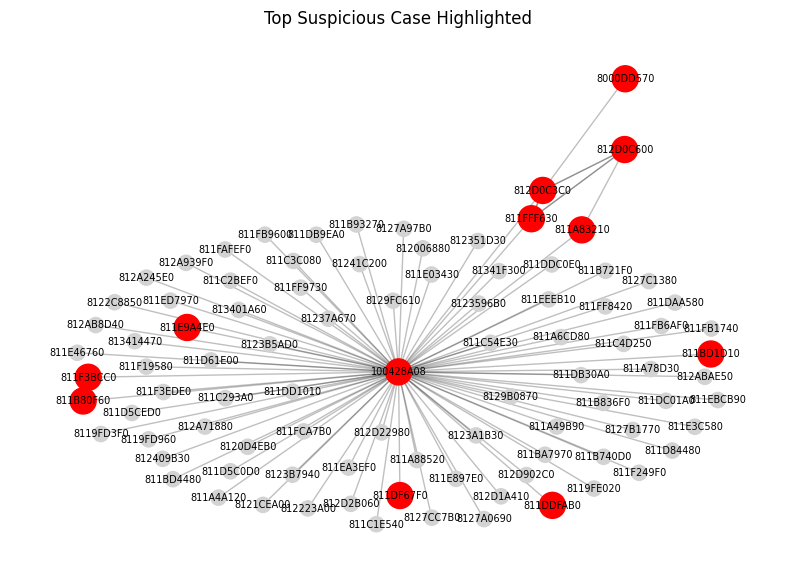

Candidate 0: 8 nodes, 8 edges
Candidate 1: 30 nodes, 35 edges
Candidate 2: 30 nodes, 30 edges
Candidate 3: 30 nodes, 29 edges


In [ ]:
def visualization_subgraph(G, case_nodes=None, radius=1, max_extra_nodes=80):
    case_nodes = set(case_nodes or [])
    if not case_nodes:
        ranked = sorted(G.nodes(), key=lambda n: G.nodes[n].get("node_risk", 0.0), reverse=True)
        case_nodes = set(ranked[: min(10, len(ranked))])

    nodes_to_draw = set(case_nodes)
    frontier = set(case_nodes)

    for _ in range(radius):
        next_frontier = set()
        for node in frontier:
            next_frontier.update(G.successors(node))
            next_frontier.update(G.predecessors(node))
        nodes_to_draw.update(next_frontier)
        frontier = next_frontier

    if len(nodes_to_draw) > len(case_nodes) + max_extra_nodes:
        extra_nodes = list(nodes_to_draw - case_nodes)
        extra_nodes = sorted(
            extra_nodes,
            key=lambda n: G.nodes[n].get("node_risk", 0.0),
            reverse=True,
        )[:max_extra_nodes]
        nodes_to_draw = case_nodes | set(extra_nodes)

    return G.subgraph(nodes_to_draw).copy()


def visualize_case(G, case_nodes=None, title="Transaction Graph", radius=1):
    case_nodes = set(case_nodes or [])
    H = visualization_subgraph(G, case_nodes=case_nodes, radius=radius)
    pos = nx.spring_layout(H.to_undirected(), seed=42)
    plt.figure(figsize=(10, 7))

    node_colors = ["red" if n in case_nodes else "lightgray" for n in H.nodes()]
    node_sizes = [350 if n in case_nodes else 120 for n in H.nodes()]

    nx.draw_networkx_edges(H, pos, alpha=0.25, arrows=False)
    nx.draw_networkx_nodes(H, pos, node_color=node_colors, node_size=node_sizes)
    nx.draw_networkx_labels(H, pos, font_size=7)
    plt.title(title)
    plt.axis("off")
    plt.show()


if final_cases:
    visualize_case(G, final_cases[0]["nodes"], title="Top Suspicious Case Highlighted", radius=1)

else:
    visualize_case(G, title="Highest-risk Neighborhood")
for i, sg in enumerate(candidate_subgraphs[:4]):
    print(f"Candidate {i}: {sg.number_of_nodes()} nodes, {sg.number_of_edges()} edges")